##### ARTI 560 - Computer Vision  

## Depth Estimation - Exercise  

### Introduction to "Depth Anything"

[Depth Anything](https://github.com/LiheYoung/Depth-Anything) is a modern deep learning model designed for robust **monocular depth estimation.**

![image.png](attachment:image.png)

#### Key Features:
- Works on any image (indoor, outdoor, complex scenes)
- Generalizes well across datasets
- Produces high-quality and smooth depth maps
- Based on large-scale training and transformer architectures

## Pre-trained Models

Depthanything provides three models of varying scales for robust relative depth estimation:

| Model                     | Params |
|--------------------------|--------|
| Depth-Anything-Small     | 24.8M  |
| Depth-Anything-Base      | 97.5M  |
| Depth-Anything-Large     | 335.3M |


### Tasks  

   #### Task 1: Setup

   1. Clone the official [Depth-Anything](https://github.com/LiheYoung/Depth-Anything) repository.

   2. Navigate to the project directory.

   3. Create a new Conda environment with Python 3.10:
      ```bash
      conda create -n depth-anything python=3.10
      conda activate depth-anything
      ```

   4. Install the required dependencies:
      ```bash
      pip install -r requirements.txt
      ```


   #### Task 2: Run Inference  

   1. Select two images of your choice *(you may also use samples from the assets folder).*
   2. Run depth estimation on the first image and generate a grayscale depth map.
   3. Run depth estimation on the second image and generate a color depth map.
   4. Generate the depth map for one video of your choice.
  

### Important Note (SSL Certificate Issue Fix)

If you encounter an SSL certificate error during setup or downloading model weights, use the following workaround:

Add this at the top of your **run.py and run_video.py** files:
```bash
import os
import certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
```

### Submission Requirements  
- Include screenshots showing successful execution of:
   - Grayscale image depth estimation output
   - Color image depth estimation output
   - Video depth estimation output
   - Screenshots of the terminal commands used to generate all three outputs above

In [8]:
!git clone https://github.com/LiheYoung/Depth-Anything.git
%cd Depth-Anything
!pip install -r requirements.txt

Cloning into 'Depth-Anything'...
remote: Enumerating objects: 441, done.
remote: Total 441 (delta 0), reused 0 (delta 0), pack-reused 441 (from 1)
Receiving objects: 100% (441/441), 237.90 MiB | 43.13 MiB/s, done.
Resolving deltas: 100% (153/153), done.
Updating files: 100% (220/220), done.
/content/arti560-computer-vision-labs/Depth-Anything/Depth-Anything


In [9]:
import os
import certifi

os.environ['SSL_CERT_FILE'] = certifi.where()

In [10]:
from google.colab import files

uploaded = files.upload()
print("Uploaded files:")
for name in uploaded.keys():
    print(name)

Saving video.mp4 to video.mp4
Saving image2.jpg to image2.jpg
Saving image1.jpg to image1.jpg
Uploaded files:
video.mp4
image2.jpg
image1.jpg


In [11]:
!ls -lh

total 2.8M
-rw-r--r-- 1 root root 3.4K May  8 22:22 app.py
drwxr-xr-x 6 root root 4.0K May  8 22:22 assets
drwxr-xr-x 2 root root 4.0K May  8 22:22 controlnet
drwxr-xr-x 3 root root 4.0K May  8 22:22 depth_anything
-rw-r--r-- 1 root root 5.3K May  8 22:22 gallery.md
-rw-r--r-- 1 root root  11K May  8 22:23 image1.jpg
-rw-r--r-- 1 root root 7.5K May  8 22:23 image2.jpg
-rw-r--r-- 1 root root  12K May  8 22:22 LICENSE
drwxr-xr-x 4 root root 4.0K May  8 22:22 metric_depth
-rw-r--r-- 1 root root  15K May  8 22:22 README.md
-rw-r--r-- 1 root root   81 May  8 22:22 requirements.txt
-rw-r--r-- 1 root root 4.3K May  8 22:22 run.py
-rw-r--r-- 1 root root 3.6K May  8 22:22 run_video.py
drwxr-xr-x 3 root root 4.0K May  8 22:22 semseg
drwxr-xr-x 3 root root 4.0K May  8 22:22 torchhub
-rw-r--r-- 1 root root 2.7M May  8 22:23 video.mp4


In [12]:
!python run.py --encoder vits --img-path image1.jpg --outdir outputs_grayscale --grayscale

xFormers not available
xFormers not available
Total parameters: 24.79M
100% 1/1 [00:00<00:00,  2.48it/s]


Generated grayscale outputs:
outputs_grayscale/image1_img_depth.png


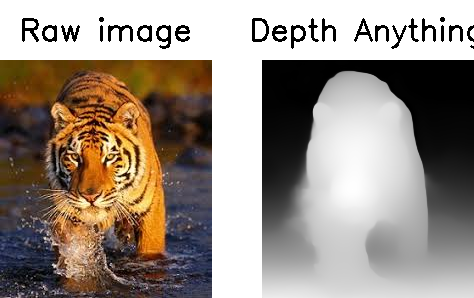

In [13]:
import os
from IPython.display import Image, display

print("Generated grayscale outputs:")
!find outputs_grayscale -type f

for root, dirs, files in os.walk("outputs_grayscale"):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            display(Image(filename=os.path.join(root, file)))

In [14]:
!python run.py --encoder vits --img-path image2.jpg --outdir outputs_color

xFormers not available
xFormers not available
Total parameters: 24.79M
100% 1/1 [00:00<00:00,  2.54it/s]


Generated color outputs:
outputs_color/image2_img_depth.png


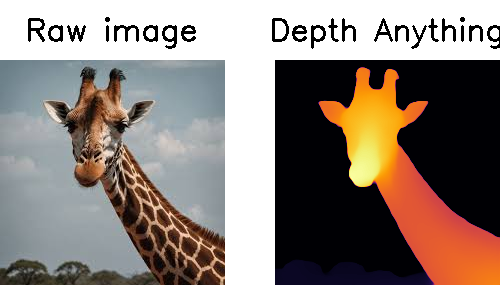

In [15]:
import os
from IPython.display import Image, display

print("Generated color outputs:")
!find outputs_color -type f

for root, dirs, files in os.walk("outputs_color"):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            display(Image(filename=os.path.join(root, file)))

In [16]:
!python run_video.py --encoder vits --video-path video.mp4 --outdir outputs_video

xFormers not available
xFormers not available
Total parameters: 24.79M
Progress 1/1, Processing video.mp4


In [17]:
print("Generated video outputs:")
!find outputs_video -type f

Generated video outputs:
outputs_video/video_video_depth.mp4


In [19]:
!zip -r depth_anything_outputs.zip outputs_grayscale outputs_color outputs_video
from google.colab import files
files.download("depth_anything_outputs.zip")

  adding: outputs_grayscale/ (stored 0%)
  adding: outputs_grayscale/image1_img_depth.png (deflated 6%)
  adding: outputs_color/ (stored 0%)
  adding: outputs_color/image2_img_depth.png (deflated 7%)
  adding: outputs_video/ (stored 0%)
  adding: outputs_video/video_video_depth.mp4 (deflated 1%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>